# Forecasting Models

## Import Libraries

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from prophet import Prophet
from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

pd.set_option("display.max_columns", None)

## Load Engineered Dataset

In [47]:
# load engineered dataset

df = pd.read_csv("../data/engineered_sales_data.csv")

In [48]:
# convert Date back into a datetime

df["Date"] = pd.to_datetime(df["Date"])

In [49]:
# inspect data in this cell and the next one
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 25 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   Store            421570 non-null  int64         
 1   Dept             421570 non-null  int64         
 2   Date             421570 non-null  datetime64[us]
 3   Weekly_Sales     421570 non-null  float64       
 4   IsHoliday        421570 non-null  bool          
 5   Temperature      421570 non-null  float64       
 6   Fuel_Price       421570 non-null  float64       
 7   MarkDown1        150681 non-null  float64       
 8   MarkDown2        111248 non-null  float64       
 9   MarkDown3        137091 non-null  float64       
 10  MarkDown4        134967 non-null  float64       
 11  MarkDown5        151432 non-null  float64       
 12  CPI              421570 non-null  float64       
 13  Unemployment     421570 non-null  float64       
 14  Type             421570 non-nul

In [50]:
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size,Year,Month,Quarter,Week,Lag_1,Lag_4,Lag_52,Rolling_Mean_4,Rolling_Mean_12
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315,2010,2,1,5,NaN,NaN,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315,2010,2,1,6,24924.50,NaN,NaN,NaN,NaN
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315,2010,2,1,7,46039.49,NaN,NaN,NaN,NaN
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315,2010,2,1,8,41595.55,NaN,NaN,NaN,NaN
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315,2010,3,1,9,19403.54,24924.5,NaN,32990.77,NaN


## Prepare Data for Modeling

In [51]:
# check missing values in modeling-related columns

modeling_columns = [
    "Weekly_Sales",
    "Lag_1",
    "Lag_4",
    "Lag_52",
    "Rolling_Mean_4",
    "Rolling_Mean_12"
]

df[modeling_columns].isnull().sum()

Weekly_Sales            0
Lag_1                3331
Lag_4               13134
Lag_52             160487
Rolling_Mean_4      13134
Rolling_Mean_12     38615
dtype: int64

In [52]:
# dropping rows that do not have a previous year

df_model = df.dropna(
    subset=[
        "Lag_52",
        "Rolling_Mean_12"
    ]
).copy()

In [53]:
# verifying we have retained what we want

print(df_model.shape)

df_model[
    [
        "Lag_1",
        "Lag_4",
        "Lag_52",
        "Rolling_Mean_4",
        "Rolling_Mean_12"
    ]
].isnull().sum()

(261083, 25)


Lag_1              0
Lag_4              0
Lag_52             0
Rolling_Mean_4     0
Rolling_Mean_12    0
dtype: int64

## Train/Test Split

In [54]:
# inspect the date range

print("Start Date:", df_model["Date"].min())
print("End Date:", df_model["Date"].max())

Start Date: 2011-02-04 00:00:00
End Date: 2012-10-26 00:00:00


In [55]:
# number of unique weeks

print(df_model["Date"].nunique())

91


### Chronological Train/Test Split

In [56]:
# determine the chronological 80% train/test split date

unique_dates = sorted(df_model["Date"].unique())

split_date = unique_dates[int(len(unique_dates) * 0.8)] # 80% cutoff

print("Split Date:", split_date)

Split Date: 2012-06-22 00:00:00


In [57]:
# create chronological train and test sets

train = df_model[df_model["Date"] < split_date].copy()
test = df_model[df_model["Date"] >= split_date].copy()

print("Training observations:", train.shape)
print("Testing observations:", test.shape)

Training observations: (205879, 25)
Testing observations: (55204, 25)


In [58]:
# Verify split is sound -- compare training end and testing start dates

print("Training End:", train["Date"].max())
print("Testing Start:", test["Date"].min())

Training End: 2012-06-15 00:00:00
Testing Start: 2012-06-22 00:00:00


## Baseline Forecast

### Naive Forecast (Last Week's Sales)

In [59]:
# use last week's sales as the prediction

test["Prediction"] = test["Lag_1"]

In [60]:
# aggregate baseline predictions by week

baseline_results = (
    test.groupby("Date")[["Weekly_Sales", "Prediction"]]
        .sum()
        .reset_index()
)

In [61]:
# evaluate the baseline

mae = mean_absolute_error(
    baseline_results["Weekly_Sales"],
    baseline_results["Prediction"]
)

rmse = np.sqrt(
    mean_squared_error(
        baseline_results["Weekly_Sales"],
        baseline_results["Prediction"]
    )
)

print(f"MAE : ${mae:,.2f}")
print(f"RMSE: ${rmse:,.2f}")

MAE : $1,590,068.12
RMSE: $2,314,371.06


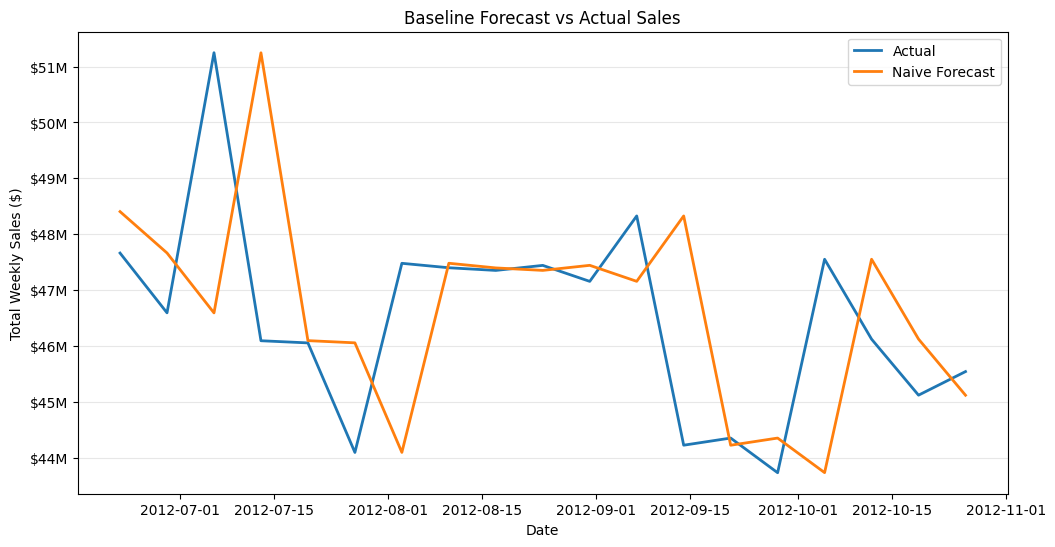

In [62]:
# visualize predictions

# aggregate actual and predicted sales
baseline_results = (
    test.groupby("Date")[["Weekly_Sales", "Prediction"]]
        .sum()
        .reset_index()
)

# plot

plt.figure(figsize=(12,6))

plt.plot(
    baseline_results["Date"],
    baseline_results["Weekly_Sales"],
    label="Actual",
    linewidth=2
)

plt.plot(
    baseline_results["Date"],
    baseline_results["Prediction"],
    label="Naive Forecast",
    linewidth=2
)

plt.title("Baseline Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.0f}M')
)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.show()


### Observations

- The naive forecast uses the previous week's sales as the prediction for the current week.

- Overall, the model follows the general level and direction of weekly sales but struggles to capture abrupt increases and decreases.

- This baseline provides a simple benchmark against which more advanced forecasting models will be evaluated.

## Prophet Forecast

1. Prepare the data for Prophet
2. Train the model
3. Generate predictions
4. Evaluate performance
5. Visualize predictions
6. Add observations

In [63]:
# aggregate total weekly sales

prophet_df = (
    df_model.groupby("Date")["Weekly_Sales"]
            .sum()
            .reset_index()
)

In [64]:
# glance at the prophet df

prophet_df.head()

,Date,Weekly_Sales
0,2011-02-04,45952516.21
1,2011-02-11,46914519.77
2,2011-02-18,48090620.49
3,2011-02-25,44040231.35
4,2011-03-04,46904056.97


In [65]:
# rename columns

prophet_df = prophet_df.rename(
    columns={
        "Date": "ds",
        "Weekly_Sales": "y"
    }
)

prophet_df.head()

,ds,y
0,2011-02-04,45952516.21
1,2011-02-11,46914519.77
2,2011-02-18,48090620.49
3,2011-02-25,44040231.35
4,2011-03-04,46904056.97


In [66]:
# create the same chronological split

split_date = prophet_df["ds"].sort_values().iloc[
    int(len(prophet_df) * 0.8)
]

train_prophet = prophet_df[
    prophet_df["ds"] < split_date
].copy()

test_prophet = prophet_df[
    prophet_df["ds"] >= split_date
].copy()

In [67]:
print(train_prophet.shape)
print(test_prophet.shape)

print(train_prophet["ds"].max())
print(test_prophet["ds"].min())

(72, 2)
(19, 2)
2012-06-15 00:00:00
2012-06-22 00:00:00


In [68]:
# train the model

model = Prophet()

model.fit(train_prophet)

16:47:49 - cmdstanpy - INFO - Chain [1] start processing
16:47:50 - cmdstanpy - INFO - Chain [1] done processing


In [69]:
# generate future dates

future = model.make_future_dataframe(
    periods=len(test_prophet),
    freq="W-FRI"
)

In [70]:
# generate predictions

forecast = model.predict(future)

forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2011-02-04,4.560368e+07,3.867513e+07,5.199407e+07,4.560368e+07,4.560368e+07,0.0,0.0,0.0,0.0,0.0,0.0,4.560368e+07
1,2011-02-11,4.564836e+07,3.915518e+07,5.206641e+07,4.564836e+07,4.564836e+07,0.0,0.0,0.0,0.0,0.0,0.0,4.564836e+07
2,2011-02-18,4.569304e+07,3.885464e+07,5.221710e+07,4.569304e+07,4.569304e+07,0.0,0.0,0.0,0.0,0.0,0.0,4.569304e+07
3,2011-02-25,4.573772e+07,3.923740e+07,5.202890e+07,4.573772e+07,4.573772e+07,0.0,0.0,0.0,0.0,0.0,0.0,4.573772e+07
4,2011-03-04,4.578240e+07,3.908671e+07,5.233862e+07,4.578240e+07,4.578240e+07,0.0,0.0,0.0,0.0,0.0,0.0,4.578240e+07


In [71]:
# keep only what we need

forecast = forecast[
    [
        "ds",
        "yhat"
    ]
]

In [72]:
# keep only the test period

forecast_test = forecast[
    forecast["ds"] >= split_date
].copy()

In [73]:
# Verify

forecast_test.head()

,ds,yhat
72,2012-06-22,4.877774e+07
73,2012-06-29,4.882091e+07
74,2012-07-06,4.886408e+07
75,2012-07-13,4.890725e+07
76,2012-07-20,4.895042e+07


In [74]:
# merge actual and predicted values

prophet_results = test_prophet.merge(
    forecast_test,
    on="ds",
    how="left"
)

In [75]:
# Verify

prophet_results.head()

,ds,y,yhat
0,2012-06-22,47661483.49,4.877774e+07
1,2012-06-29,46591796.81,4.882091e+07
2,2012-07-06,51247302.43,4.886408e+07
3,2012-07-13,46092456.18,4.890725e+07
4,2012-07-20,46053541.91,4.895042e+07


In [76]:
# Calculate metrics

prophet_mae = mean_absolute_error(
    prophet_results["y"],
    prophet_results["yhat"]
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_results["y"],
        prophet_results["yhat"]
    )
)

print(f"MAE : ${prophet_mae:,.2f}")
print(f"RMSE: ${prophet_rmse:,.2f}")

MAE : $2,915,924.86
RMSE: $3,255,605.23


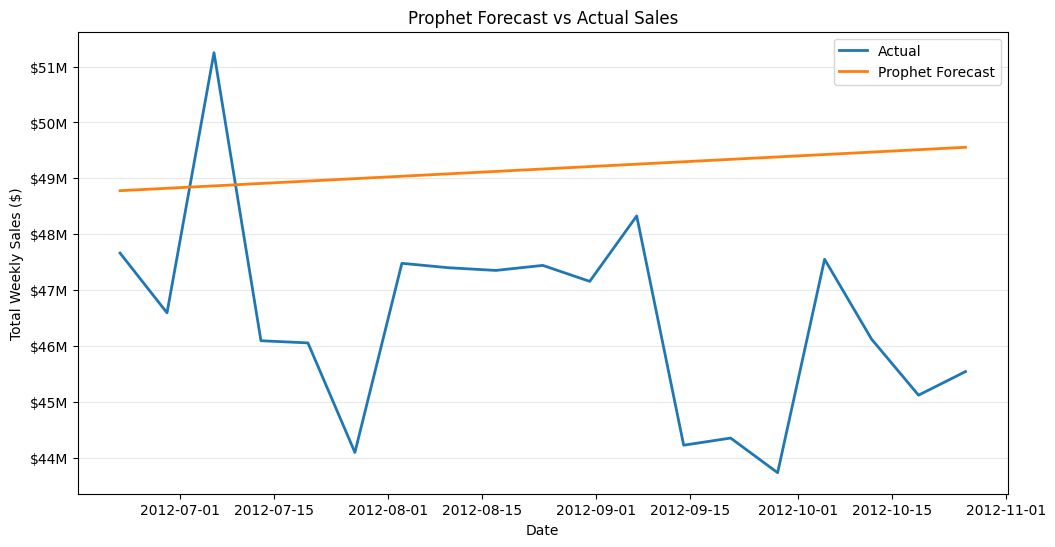

In [77]:
# Visualize the forecast

plt.figure(figsize=(12, 6))

plt.plot(
    prophet_results["ds"],
    prophet_results["y"],
    label="Actual",
    linewidth=2
)

plt.plot(
    prophet_results["ds"],
    prophet_results["yhat"],
    label="Prophet Forecast",
    linewidth=2
)

plt.title("Prophet Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales ($)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.0f}M')
)

plt.grid(axis="y", alpha=0.3)

plt.legend()

plt.show()

### Observations

- Prophet captures the overall level and gradual trend of weekly sales but produces a relatively smooth forecast over the test period.

- The model does not capture the sharper week-to-week fluctuations observed in the actual sales.

- On the test set, Prophet achieved an MAE of approximately $2.92 million and an RMSE of approximately $3.26 million.

- The naive baseline outperformed Prophet on both evaluation metrics, suggesting that recent sales were a stronger predictor of short-term demand than Prophet's trend-based forecast for this dataset.

## XGBoost Forecast

In [78]:
# select the features

features = [
    "Store",
    "Dept",
    "IsHoliday",
    "Temperature",
    "Fuel_Price",
    "CPI",
    "Unemployment",
    "Size",
    "Year",
    "Quarter",
    "Month",
    "Week",
    "Lag_1",
    "Lag_4",
    "Lag_52",
    "Rolling_Mean_4",
    "Rolling_Mean_12"
]

In [79]:
# preprocessing inspection

df_model["Type"].value_counts()

Type
A    134116
B    101369
C     25598
Name: count, dtype: int64

In [80]:
# encode store type for XGBoost

type_mapping = {
    "A": 0,
    "B": 1,
    "C": 2
}

df_model["Type"] = df_model["Type"].map(type_mapping)

In [81]:
# encode categorical features

features.append("Type")

In [82]:
# recreate the train/test sets using the updated dataframe

train = df_model[df_model["Date"] < split_date].copy()
test = df_model[df_model["Date"] >= split_date].copy()

# build X matrices

X_train = train[features]
y_train = train["Weekly_Sales"]

X_test = test[features]
y_test = test["Weekly_Sales"]

### Train the XGBoost Model

In [83]:
# initialize the XGBoost model

xgb_model = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [84]:
# train the model

xgb_model.fit(
    X_train,
    y_train
)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [85]:
# generate predictions on the test set

xgb_predictions = xgb_model.predict(X_test)

In [86]:
# evaluate the model

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

print(f"MAE : ${xgb_mae:,.2f}")
print(f"RMSE: ${xgb_rmse:,.2f}")

MAE : $1,293.84
RMSE: $2,700.80


In [87]:
# aggregate predictions by week

xgb_results = test.copy()

xgb_results["Prediction"] = xgb_predictions

xgb_results = (
    xgb_results
        .groupby("Date")[["Weekly_Sales", "Prediction"]]
        .sum()
        .reset_index()
)

In [88]:
xgb_mae_agg = mean_absolute_error(
    xgb_results["Weekly_Sales"],
    xgb_results["Prediction"]
)

xgb_rmse_agg = np.sqrt(
    mean_squared_error(
        xgb_results["Weekly_Sales"],
        xgb_results["Prediction"]
    )
)

print(f"Aggregated MAE : ${xgb_mae_agg:,.2f}")
print(f"Aggregated RMSE: ${xgb_rmse_agg:,.2f}")

Aggregated MAE : $1,122,419.95
Aggregated RMSE: $1,411,355.28


## Model Performance Comparison

In [89]:
comparison = pd.DataFrame({
    "Model": ["Naive", "Prophet", "XGBoost"],
    "MAE": [
        mae,
        prophet_mae,
        xgb_mae_agg
    ],
    "RMSE": [
        rmse,
        prophet_rmse,
        xgb_rmse_agg
    ]
})

comparison.style.format({
    "MAE": "${:,.0f}",
    "RMSE": "${:,.0f}"
})

,Model,MAE,RMSE
0,Naive,"$1,590,068","$2,314,371"
1,Prophet,"$2,915,925","$3,255,605"
2,XGBoost,"$1,122,420","$1,411,355"


### Observations

- XGBoost achieved the lowest MAE and RMSE of the three models.
- The naive baseline performed surprisingly well, indicating strong week-to-week persistence in sales.
- Prophet produced the largest forecasting errors on this dataset. With fewer than three years of historical data, the model likely did not have enough information to learn recurring seasonal patterns effectively.
- Overall, engineered lag and rolling features enabled XGBoost to substantially outperform the benchmark forecasting methods.

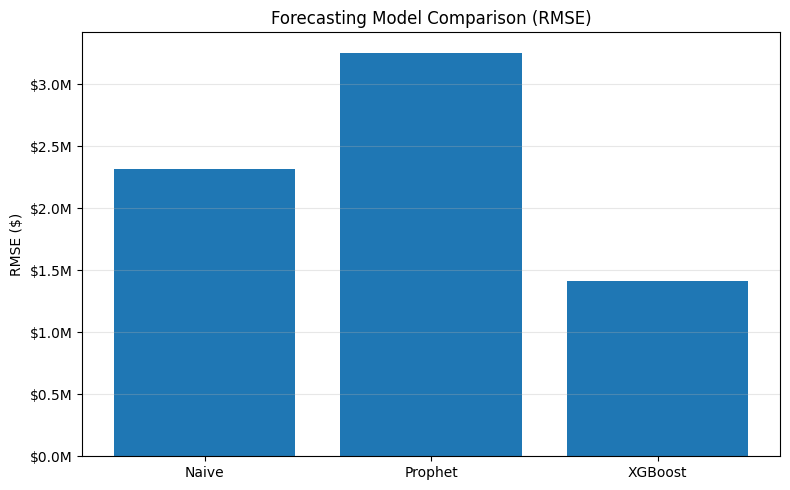

In [90]:
# RMSE comparison across models

plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["RMSE"]
)

plt.title("Forecasting Model Comparison (RMSE)")
plt.ylabel("RMSE ($)")

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'${x/1e6:.1f}M')
)

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../visuals/model_comparison_rmse.png", dpi=300, bbox_inches="tight")

plt.show()

# Summary

In this notebook, we:

- Built a naive forecasting baseline using the previous week's sales.
- Trained and evaluated a Prophet forecasting model.
- Prepared engineered features for machine learning forecasting.
- Trained an XGBoost forecasting model.
- Compared all models using MAE and RMSE.
- Found that XGBoost substantially outperformed both the naive baseline and Prophet.

The next notebook focuses on improving the XGBoost model through hyperparameter tuning and feature importance analysis.